In [845]:
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr

from shapely.geometry import Point
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

from esda.moran import Moran
from libpysal.weights import Queen

import contextily as ctx

import statsmodels.api as sm
import statsmodels.formula.api as smf

In [846]:
import warnings
warnings.filterwarnings("ignore")   

In [847]:
import os
os.chdir(os.path.dirname(os.path.abspath(__vsc_ipynb_file__)) + "/..")

In [848]:
df_org = pd.read_csv("data/processed/final_dataset_de.csv")
df = df_org.copy()
temp = pd.read_excel("data/temperature_2006_daily.xlsx")

In [849]:
# Gross Domestic Product 2006 per Capita in € | NUTS2

gdp = pd.read_csv("data/gross_domestic_product_per_capita_nuts2.csv")
gdp['State'] = [i.title() for i in gdp['State']]

In [850]:
# Disposable income and distribution accounts of households 2006 per Capita | NUTS2

inc = pd.read_csv("data/disposable_income_per_capita.csv")

In [851]:
# https://link.springer.com/article/10.1007/s00508-021-01941-9

bmi = pd.read_csv("data/weight_data_nuts2.csv")

In [852]:
df['datetime'] = pd.to_datetime(df['zeit'])

df['date'] = df['datetime'].dt.date
df['time'] = df['datetime'].dt.time

In [853]:
temp['time'] = pd.to_datetime(temp['time'])
temp['date'] = temp['time'].dt.date
temp['time'] = temp['time'].dt.time

In [854]:
df = pd.merge(df, temp, on='date')

In [855]:
bp_state = (
    df
    .groupby("bundesland")[["messwert_bp_sys", "messwert_bp_dia"]]
    .mean()
    .reset_index()
)

bp_state.columns = [
    "bundesland",
    "avg_sys_bp",
    "avg_dia_bp"
]

In [856]:
import os
print(os.getcwd())
print(os.path.exists("geospace/gadm41_AUT_1.shp"))
gdf_states = gpd.read_file("geospace/gadm41_AUT_1.shp")
gdf_states['bundesland'] = gdf_states['NAME_1']

/Users/maria/case-study
True


### GDP vs BP

In [857]:
merged_df = bp_state.merge(gdp, left_on="bundesland", right_on='State')

In [858]:
corr_sys, p_sys = pearsonr(
    merged_df["Euros"],
    merged_df["avg_sys_bp"]
)

corr_dia, p_dia = pearsonr(
    merged_df["Euros"],
    merged_df["avg_dia_bp"]
)

print("Systolic BP Correlation")
print("Correlation:", corr_sys)
print("P-value:", p_sys)

print("\nDiastolic BP Correlation")
print("Correlation:", corr_dia)
print("P-value:", p_dia)

Systolic BP Correlation
Correlation: -0.4327143258716325
P-value: 0.24470279906574058

Diastolic BP Correlation
Correlation: -0.32540409456961406
P-value: 0.3928353610124219


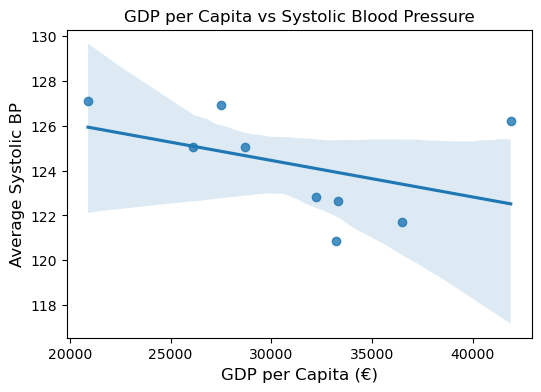

In [859]:
plt.figure(figsize=(6, 4))

sns.regplot(
    data=merged_df,
    x="Euros",
    y="avg_sys_bp"
)

plt.title("GDP per Capita vs Systolic Blood Pressure")
plt.xlabel("GDP per Capita (€)", fontsize=12)
plt.ylabel("Average Systolic BP", fontsize=12)

plt.show()

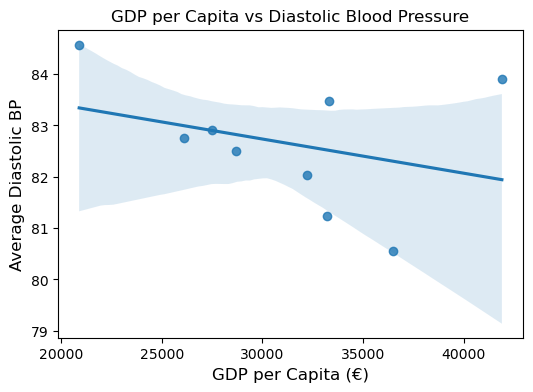

In [860]:
plt.figure(figsize=(6, 4))

sns.regplot(
    data=merged_df,
    x="Euros",
    y="avg_dia_bp"
)

plt.title("GDP per Capita vs Diastolic Blood Pressure")
plt.xlabel("GDP per Capita (€)", fontsize=12)
plt.ylabel("Average Diastolic BP", fontsize=12)

plt.show()

In [861]:
map_gdf = gdf_states.merge(
    merged_df,
    left_on="bundesland",
    right_on="State"
)

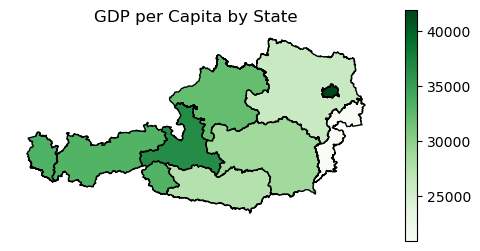

In [862]:
fig, ax = plt.subplots(1, 1, figsize=(6, 3))

map_gdf.plot(
    column="Euros",
    cmap="Greens",
    legend=True,
    edgecolor="black",
    ax=ax
)

ax.set_title("GDP per Capita by State")
ax.axis("off")

plt.show()

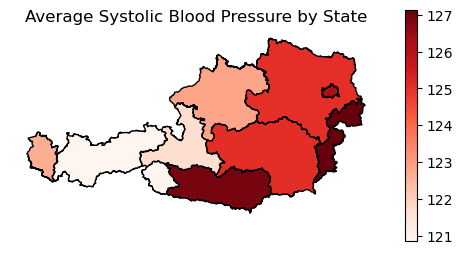

In [863]:
fig, ax = plt.subplots(1, 1, figsize=(6, 3))

map_gdf.plot(
    column="avg_sys_bp",
    cmap="Reds",
    legend=True,
    edgecolor="black",
    ax=ax
)

ax.set_title("Average Systolic Blood Pressure by State")
ax.axis("off")

plt.show()

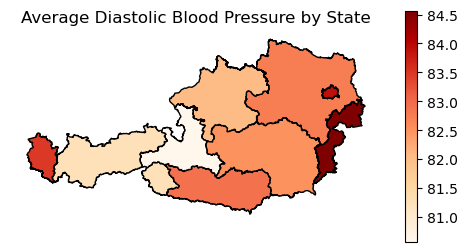

In [864]:
fig, ax = plt.subplots(1, 1, figsize=(6, 3))

map_gdf.plot(
    column="avg_dia_bp",
    cmap="OrRd",
    legend=True,
    edgecolor="black",
    ax=ax
)

ax.set_title("Average Diastolic Blood Pressure by State")
ax.axis("off")

plt.show()

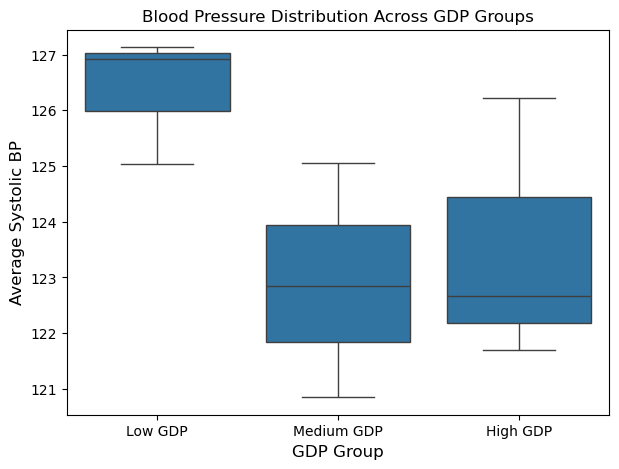

In [865]:
merged_df["gdp_group"] = pd.qcut(
    merged_df["Euros"],
    q=3,
    labels=["Low GDP", "Medium GDP", "High GDP"]
)

plt.figure(figsize=(7, 5))

sns.boxplot(
    data=merged_df,
    x="gdp_group",
    y="avg_sys_bp"
)

plt.title("Blood Pressure Distribution Across GDP Groups")
plt.xlabel("GDP Group", fontsize=12)
plt.ylabel("Average Systolic BP", fontsize=12)

plt.show()

### Income vs BP

In [866]:
merged_df = bp_state.merge(inc, left_on="bundesland", right_on='State')

In [867]:
# Merge with shapefile
map_gdf = gdf_states.merge(
    merged_df,
    left_on="bundesland",
    right_on="State"
)

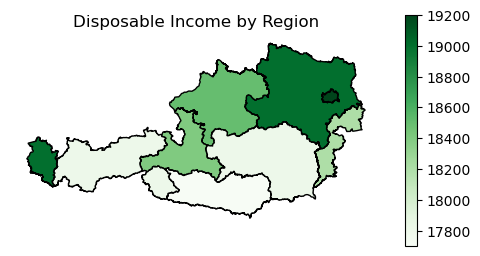

In [868]:
# Plot disposable income
fig, ax = plt.subplots(figsize=(6, 3))

map_gdf.plot(
    column="Euros",
    cmap="Greens",
    legend=True,
    edgecolor="black",
    ax=ax
)

ax.set_title("Disposable Income by Region")
ax.axis("off")

plt.show()

### Overweight vs BP

In [869]:
merged_df = bp_state.merge(bmi, left_on="bundesland", right_on='State')

In [870]:
# Merge
map_gdf = gdf_states.merge(
    merged_df,
    left_on="bundesland",
    right_on="State"
)

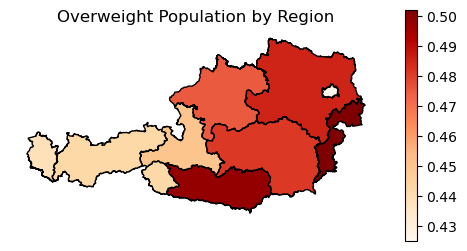

In [871]:
# Plot overweight prevalence
fig, ax = plt.subplots(figsize=(6, 3))

map_gdf.plot(
    column="Overweight (BMI >= 25)",
    cmap="OrRd",
    legend=True,
    edgecolor="black",
    ax=ax
)

ax.set_title("Overweight Population by Region")
ax.axis("off")

plt.show()

Correlation: -0.9006469743235778
P-value: 0.0009224811341753624


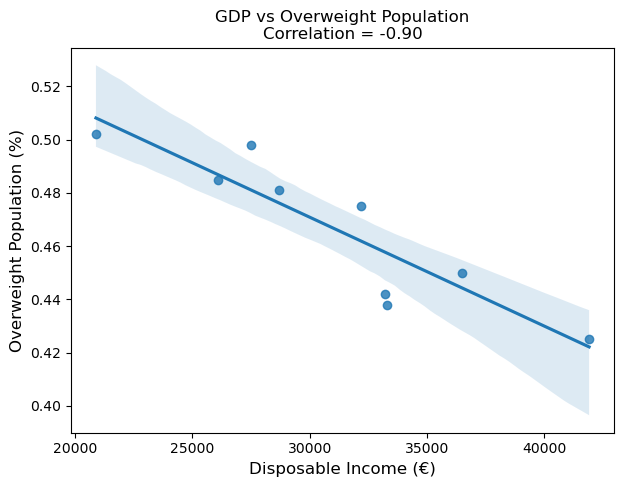

In [872]:
# Merge BMI with GDP
bmi_gdp = bmi.merge(
    gdp,
    on="State",
)

# Correlation
corr, pval = pearsonr(
    bmi_gdp["Euros"],
    bmi_gdp["Overweight (BMI >= 25)"]
)

print("Correlation:", corr)
print("P-value:", pval)

# Plot
plt.figure(figsize=(7, 5))

sns.regplot(
    data=bmi_gdp,
    x="Euros",
    y="Overweight (BMI >= 25)"
)

plt.title(
    f"GDP vs Overweight Population\nCorrelation = {corr:.2f}"
)

plt.xlabel("Disposable Income (€)", fontsize=12)
plt.ylabel("Overweight Population (%)", fontsize=12)

plt.show()

Correlation: 0.2216438762853169
P-value: 0.566549420918935


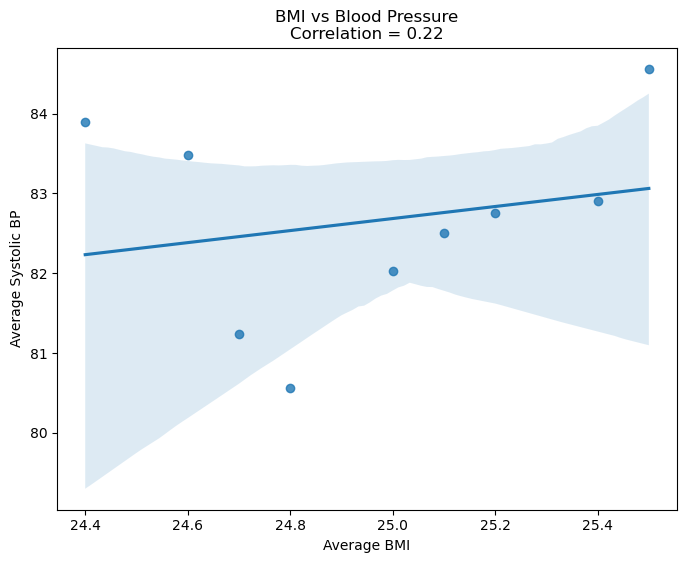

In [873]:
# Correlation
corr_bp, pval_bp = pearsonr(
    merged_df["Average BMI (kg/m²)"],
    merged_df["avg_dia_bp"]
)

print("Correlation:", corr_bp)
print("P-value:", pval_bp)

# Plot
plt.figure(figsize=(8, 6))

sns.regplot(
    data=merged_df,
    x="Average BMI (kg/m²)",
    y="avg_dia_bp"
)

plt.title(
    f"BMI vs Blood Pressure\nCorrelation = {corr_bp:.2f}"
)

plt.xlabel("Average BMI")
plt.ylabel("Average Systolic BP")

plt.show()

### NEAP

In [874]:
df_neap = df_org[df_org["postleitzahl"].map(df_org["postleitzahl"].value_counts()) > 10]

In [875]:
# neighborhood definition
group_col = "postleitzahl"

# target variable
target = "messwert_bp_sys"

df_neap["neighborhood_mean_bp"] = df_neap.groupby(group_col)[target].transform("mean")

In [876]:
df_neap["bp_minus_neighborhood"] = df_neap[target] - df_neap["neighborhood_mean_bp"]

In [877]:
df_neap["raucher"] = df_neap["raucher"].map({True: 1, False: 0})
df_neap["cholesterin_bekannt"] = df_neap["cholesterin_bekannt"].map({True: 1, False: 0})

In [878]:
X = df_neap[["geburtsjahr", "raucher", "cholesterin_bekannt"]]
X = sm.add_constant(X)
y = df_neap["messwert_bp_sys"]

model1 = sm.OLS(y, X).fit()


In [879]:
X = df_neap[["geburtsjahr", "raucher", "cholesterin_bekannt", "neighborhood_mean_bp"]]
X = sm.add_constant(X)

model2 = sm.OLS(y, X).fit()

model2.params

const                   746.757303
geburtsjahr              -0.369769
raucher                   0.491168
cholesterin_bekannt       0.553974
neighborhood_mean_bp      0.828381
dtype: float64

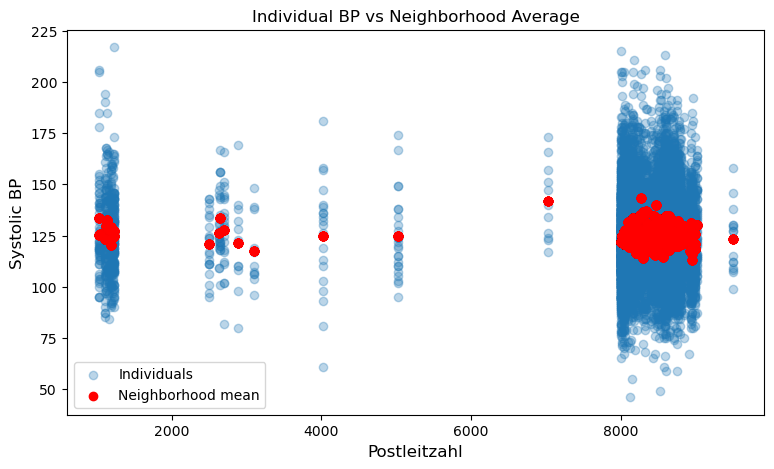

In [880]:
plt.figure(figsize=(9,5))

plt.scatter(df_neap["postleitzahl"], df_neap["messwert_bp_sys"], alpha=0.3, label="Individuals")
plt.scatter(df_neap["postleitzahl"], df_neap["neighborhood_mean_bp"], color="red", label="Neighborhood mean")

plt.xlabel("Postleitzahl", fontsize=12)
plt.ylabel("Systolic BP", fontsize=12)
plt.legend()
plt.title("Individual BP vs Neighborhood Average")
plt.show()

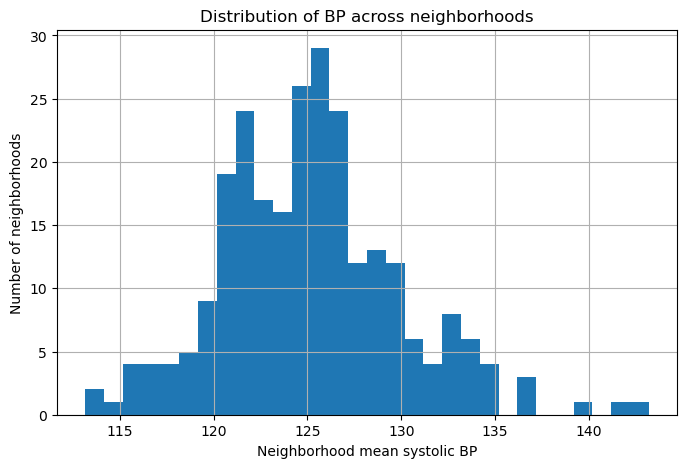

In [881]:
plt.figure(figsize=(8,5))

df_neap.groupby("postleitzahl")["messwert_bp_sys"].mean().hist(bins=30)

plt.xlabel("Neighborhood mean systolic BP")
plt.ylabel("Number of neighborhoods")
plt.title("Distribution of BP across neighborhoods")
plt.show()

In [882]:
# Drop missing values in key columns
data = df_neap.dropna(subset=["postleitzahl", "messwert_bp_sys"])

In [883]:
model = smf.mixedlm(
    "messwert_bp_sys ~ 1",
    data,
    groups=data["postleitzahl"]
).fit()

var_between = model.cov_re.iloc[0, 0]
var_within = model.scale

icc = var_between / (var_between + var_within)

icc

np.float64(0.017731775828442046)

UR match: 11,714/15,219 (77.0%)
Districts with data: 19 / 94


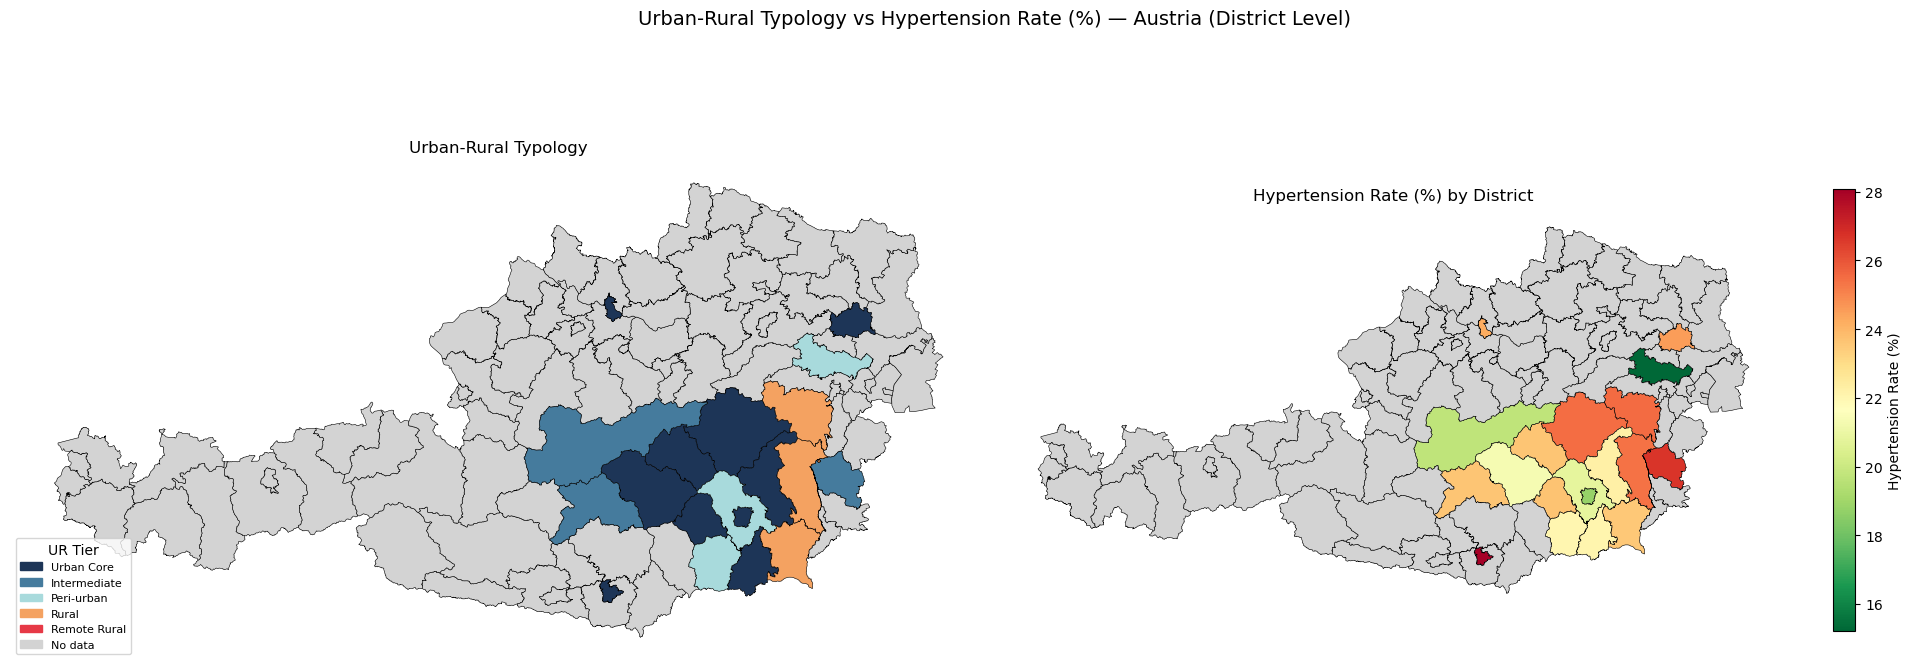

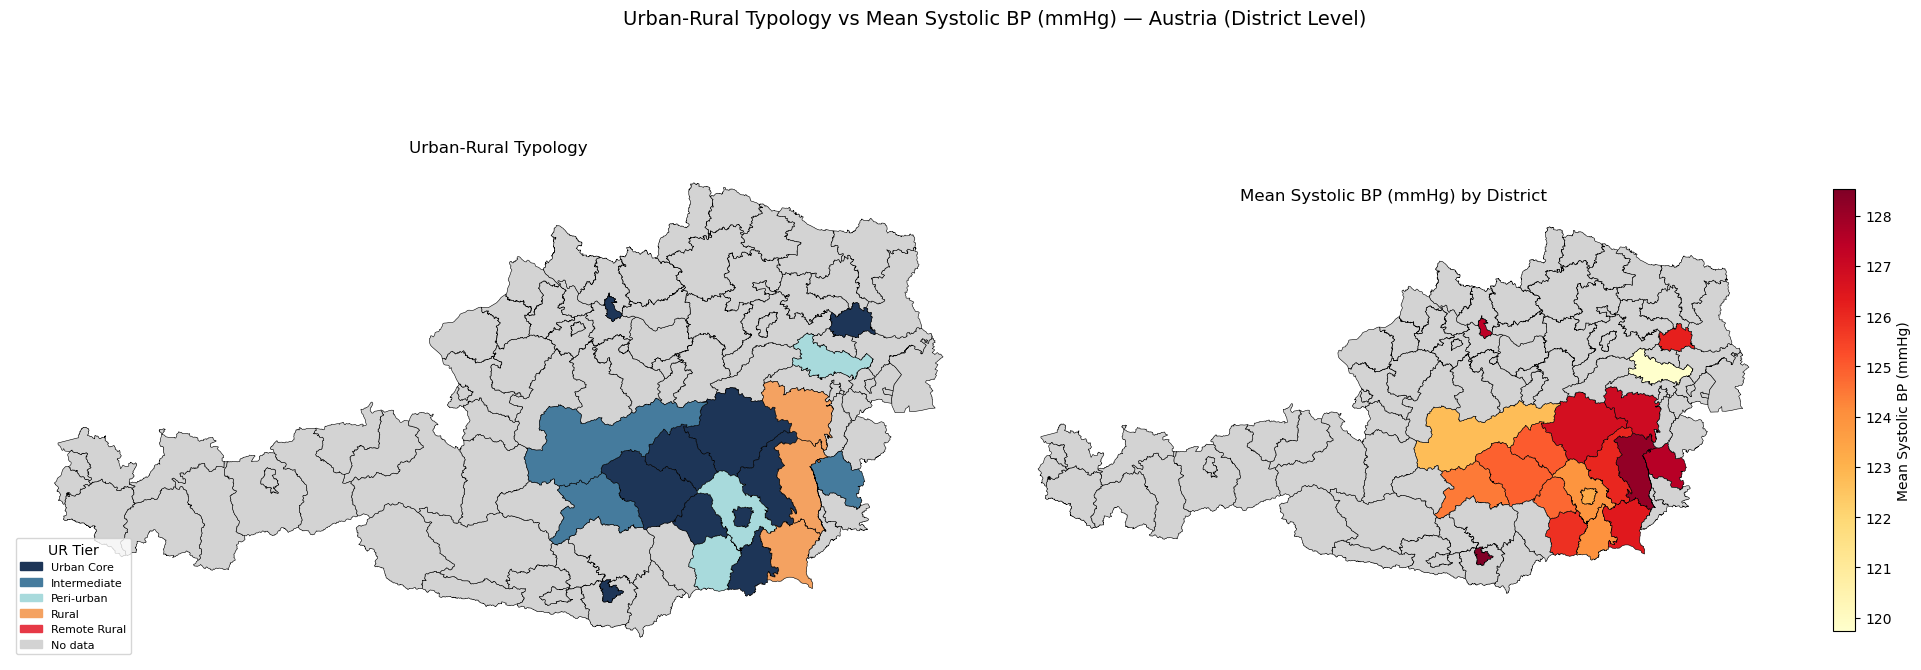

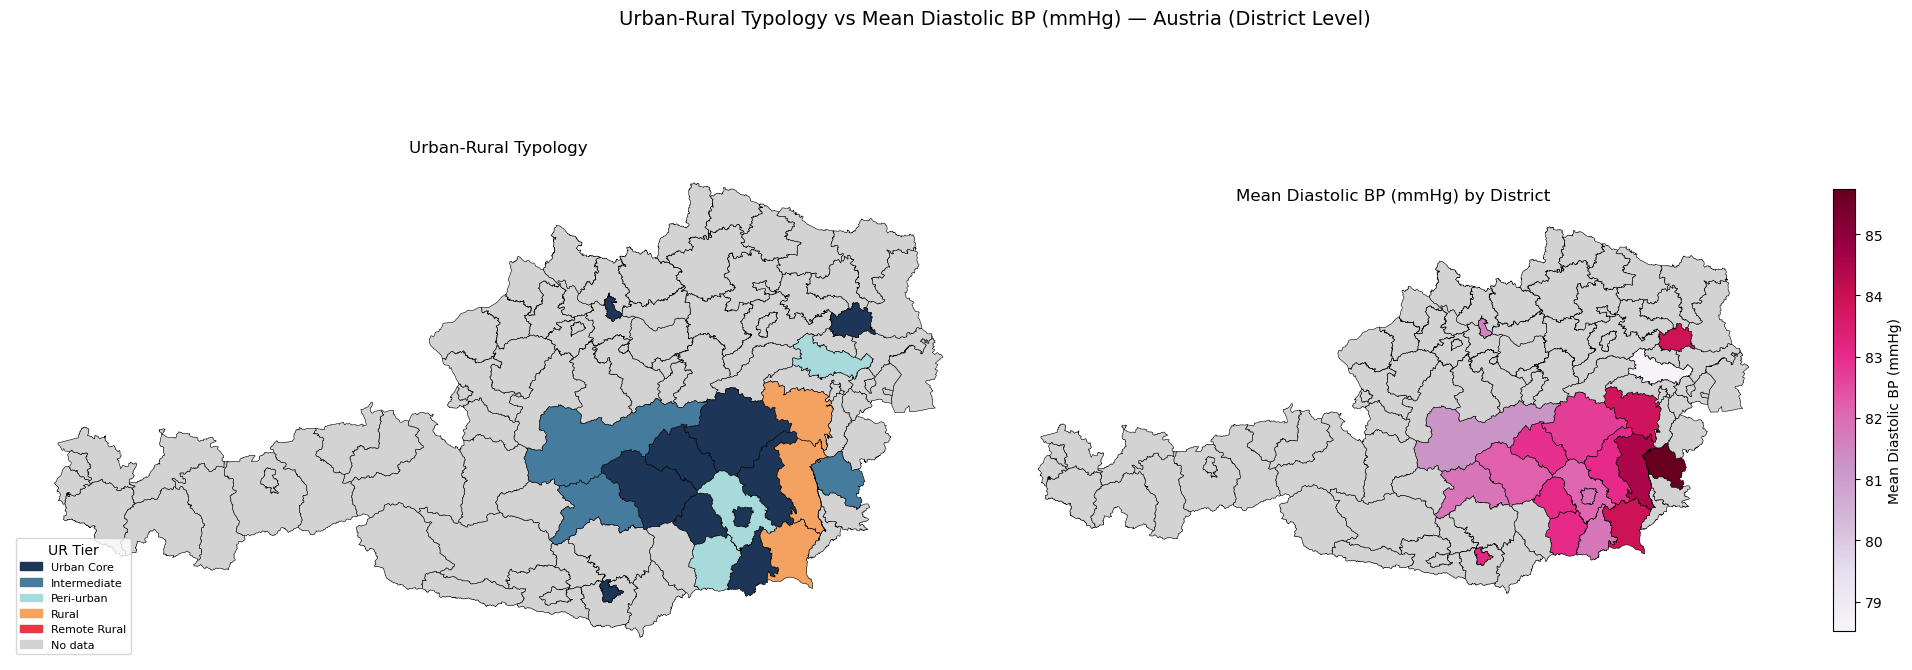

('WARNING: ', 0, ' is an island (no neighbors)')
('WARNING: ', 6, ' is an island (no neighbors)')
('WARNING: ', 10, ' is an island (no neighbors)')
('WARNING: ', 18, ' is an island (no neighbors)')
  Moran's I [hyp_rate]: I=0.1649, p=0.0930
('WARNING: ', 0, ' is an island (no neighbors)')
('WARNING: ', 6, ' is an island (no neighbors)')
('WARNING: ', 10, ' is an island (no neighbors)')
('WARNING: ', 18, ' is an island (no neighbors)')
  Moran's I [sys_mean]: I=0.2790, p=0.0400


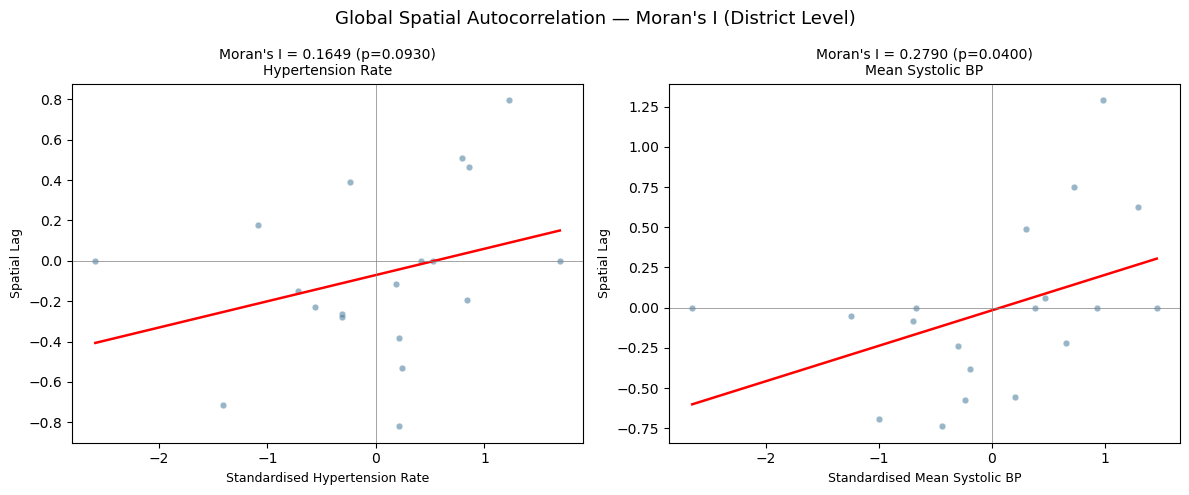

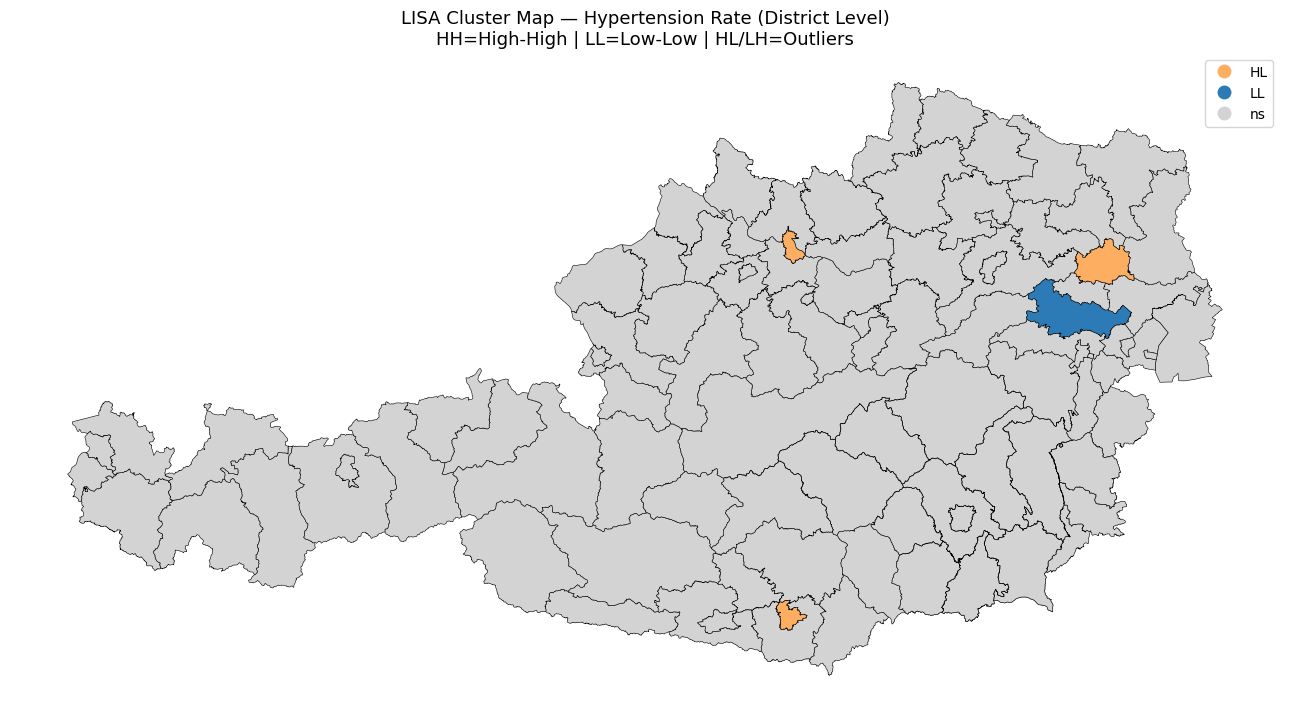

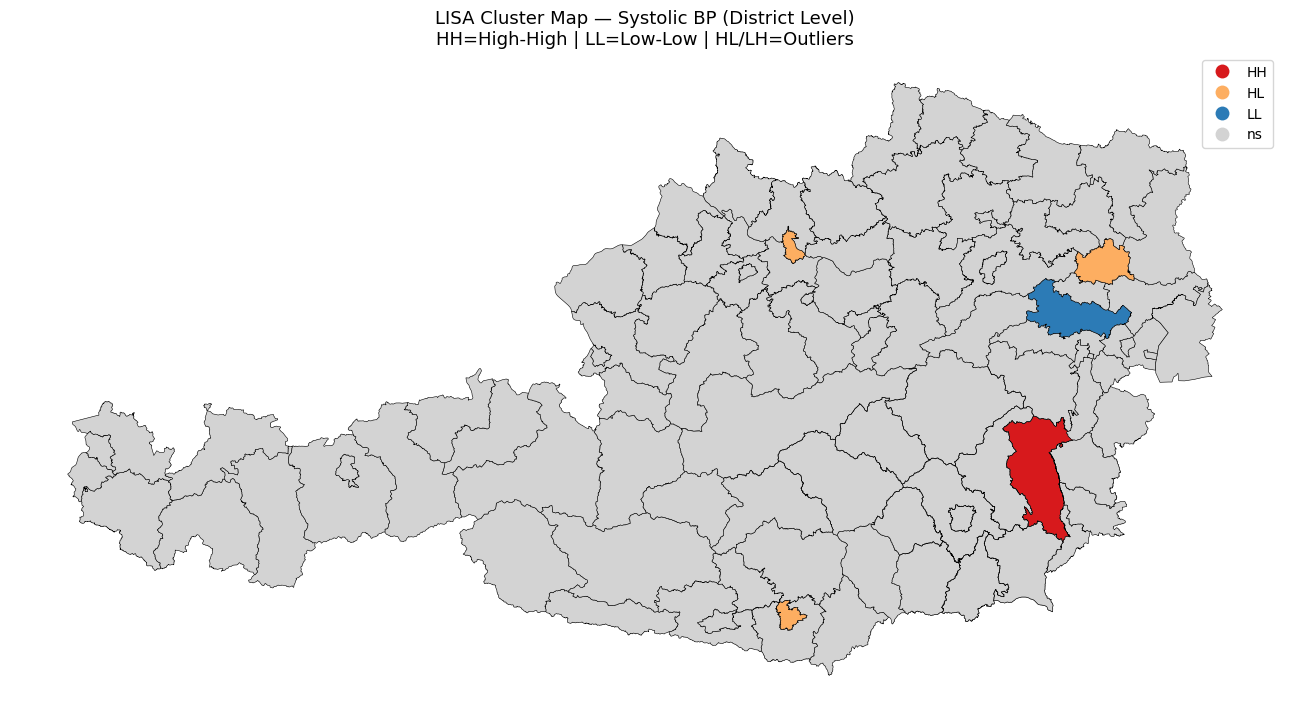


Urban-Rural Tier Summary:
     ur_tier    n  hyp_rate_pct  sys_mean  dia_mean
  Urban Core 7138         21.77    124.98     82.55
Intermediate  761         24.57    126.60     83.38
  Peri-urban 1508         23.74    124.69     82.23
       Rural 1830         22.24    125.00     82.17
Remote Rural  487         23.41    126.14     83.44
NUTS3 regions kept (≥30 patients): 21
                   nuts3  n_patients  gdp_per_capita  messwert_bp_sys  messwert_bp_dia
             Mühlviertel          47           17000       121.914894        79.659574
           Südburgenland          58           18600       123.586207        82.103448
           Oststeiermark        1935           20600       126.602584        83.571059
 West- und Südsteiermark        1268           21400       125.546530        82.861987
             Waldviertel          30           21400       131.466667        84.500000
  Wiener Umland/Nordteil          79           22400       123.810127        82.531646
          Nord

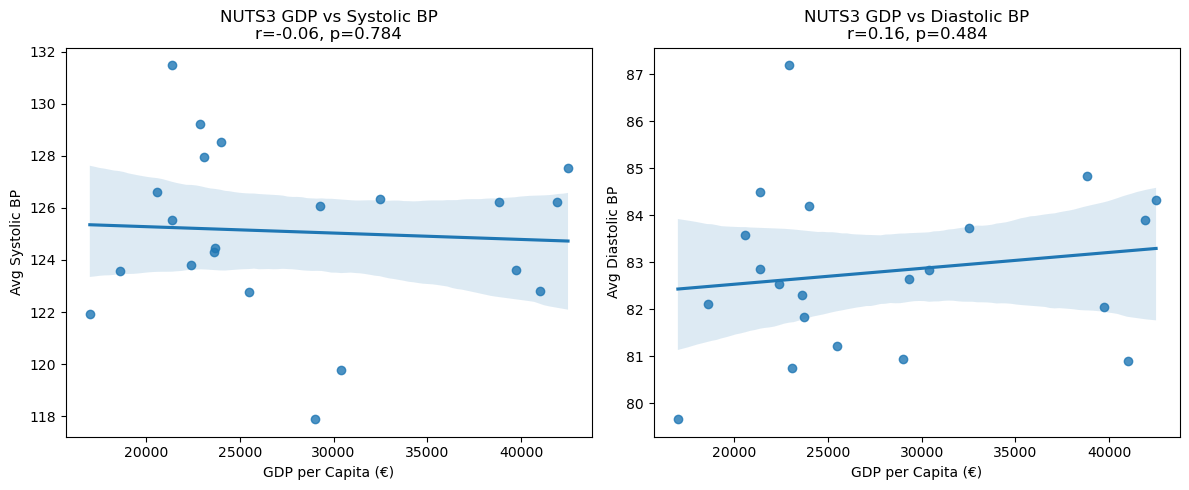

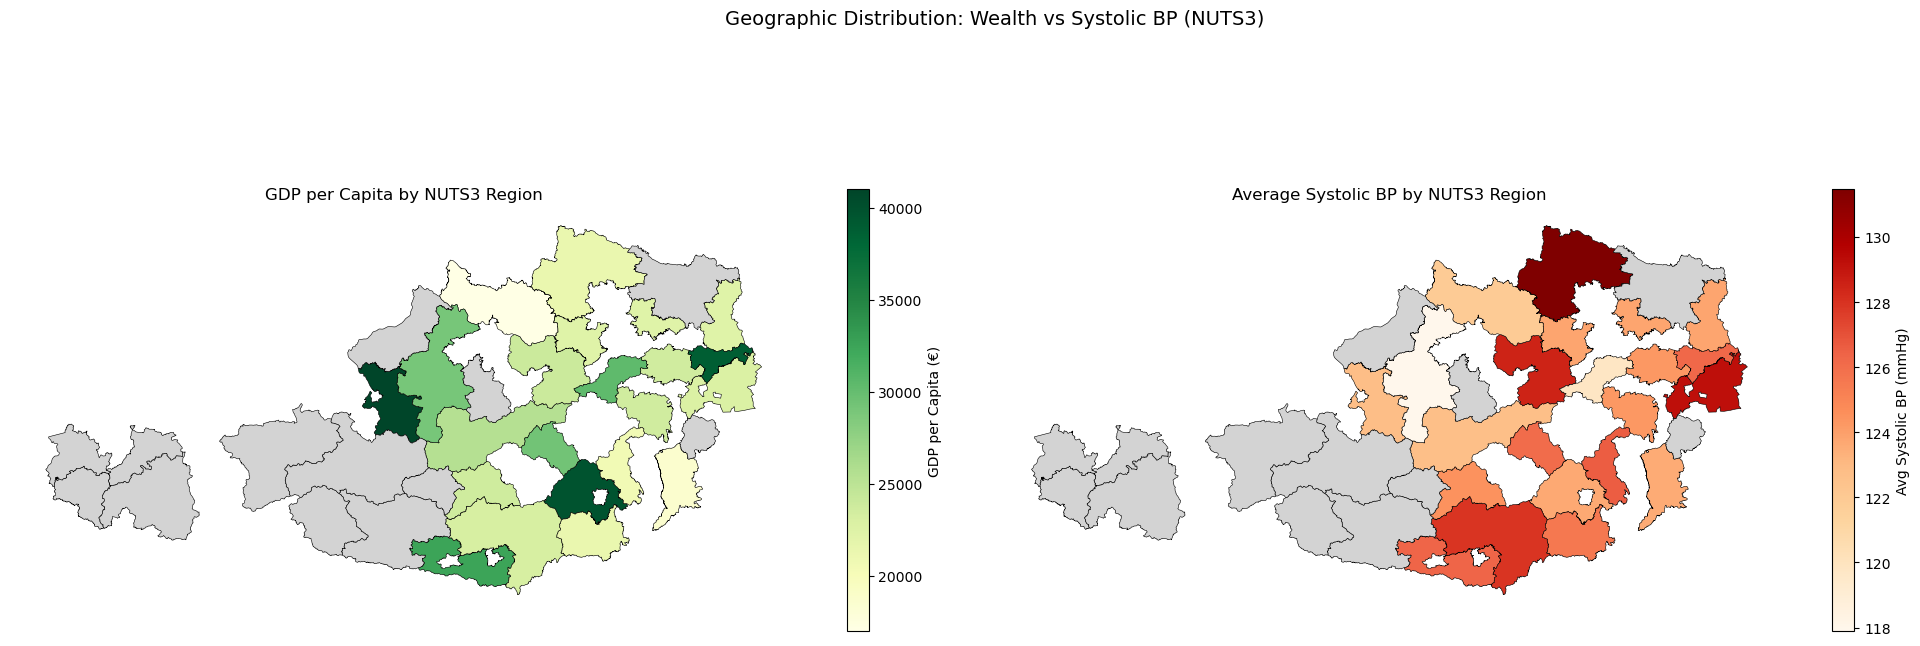

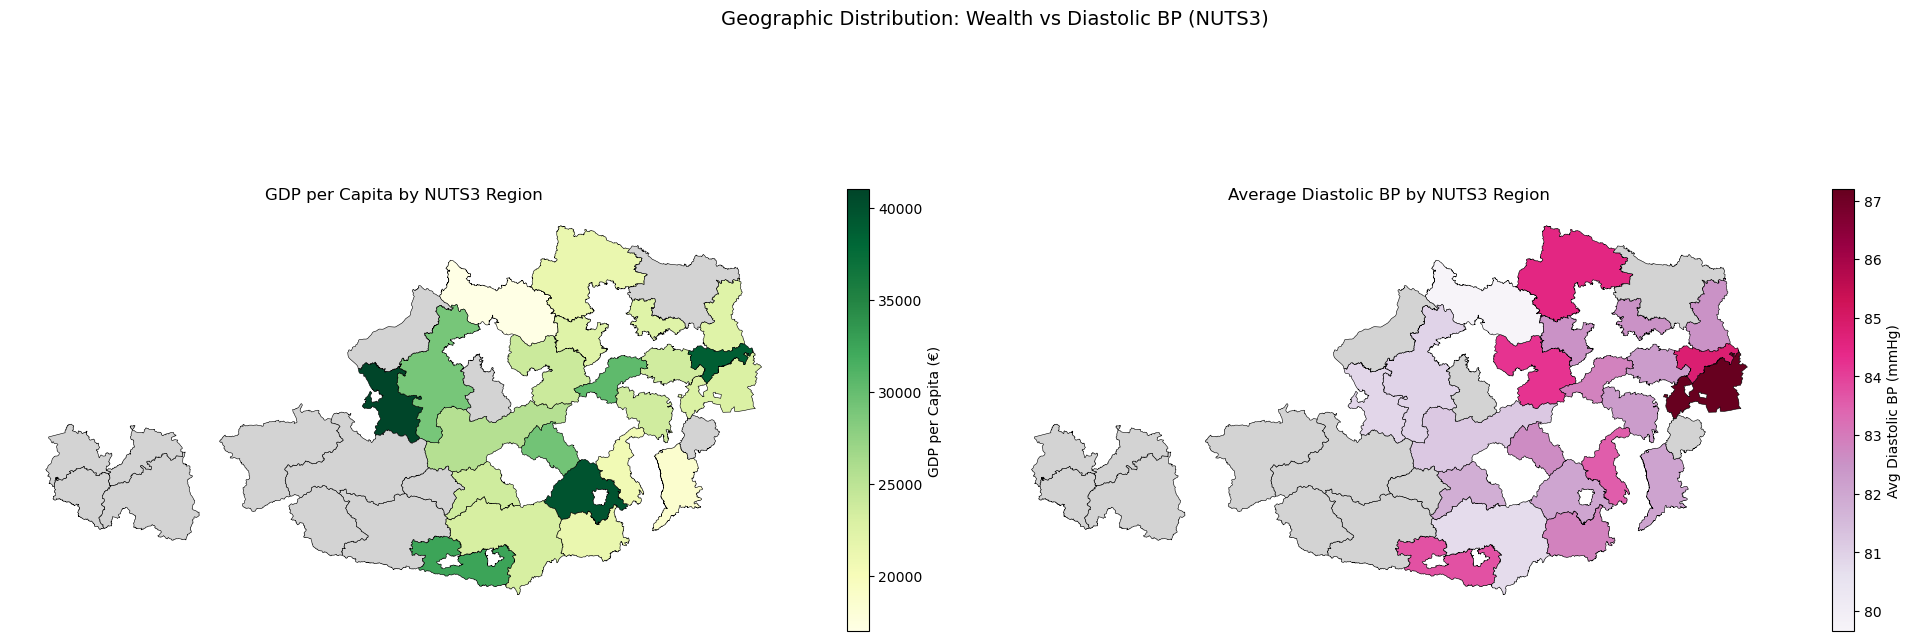

('WARNING: ', 10, ' is an island (no neighbors)')
  Moran's I [messwert_bp_sys]: I=-0.0049, p=0.3790
('WARNING: ', 10, ' is an island (no neighbors)')
  Moran's I [messwert_bp_dia]: I=0.1233, p=0.1700


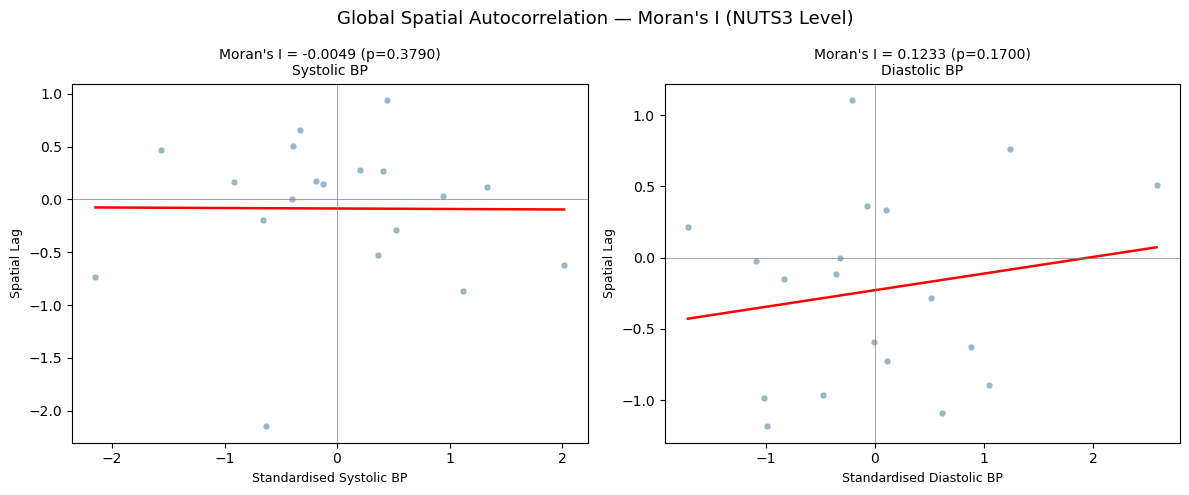

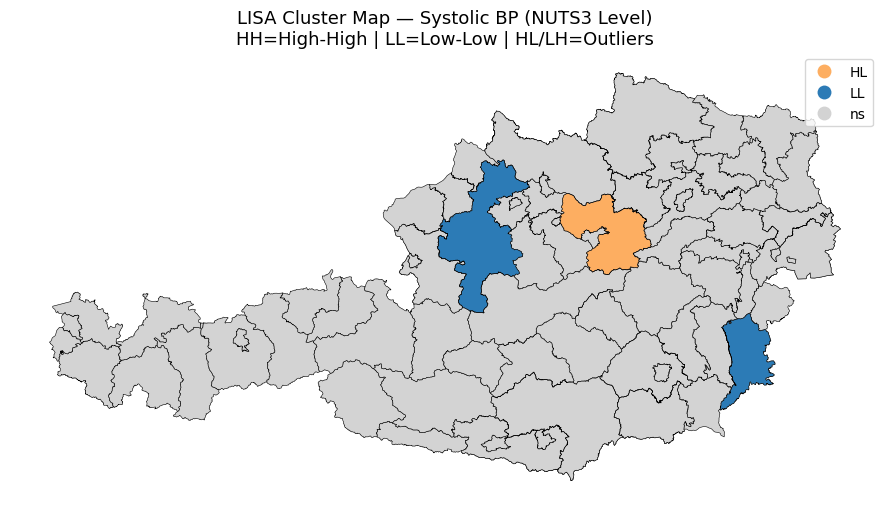

In [ ]:
import os
import json
import warnings
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy.stats import pearsonr
from libpysal.weights import Queen
from libpysal.weights.spatial_lag import lag_spatial
from esda.moran import Moran, Moran_Local
from splot.esda import lisa_cluster

warnings.filterwarnings("ignore")

DATA = "data"
GEO  = "geospace"
OUT  = "presentation/figures"
os.makedirs(OUT, exist_ok=True)

with open("data/lookups.json", encoding="utf-8") as f:
    _lut = json.load(f)

BEZIRK_MAP      = _lut["BEZIRK_MAP"]
BEZIRK_TO_NUTS3 = _lut["BEZIRK_TO_NUTS3"]
UR_TIERS        = {int(k): v for k, v in _lut["UR_TIERS"].items()}

TIER_ORDER   = ["Urban Core", "Intermediate", "Peri-urban", "Rural", "Remote Rural"]
TIER_PALETTE = {
    "Urban Core": "#1d3557", "Intermediate": "#457b9d",
    "Peri-urban": "#a8dadc", "Rural": "#f4a261", "Remote Rural": "#e63946",
}

# ── Helpers ────────────────────────────────────────────────────────────────────

def savefig(name):
    plt.tight_layout()
    plt.savefig(f"{OUT}/{name}.png", dpi=150, bbox_inches="tight")
    plt.show()


def load_district_shapefile():
    return gpd.read_file(f"{GEO}/gadm41_AUT_3.shp").dissolve(by="NAME_2").reset_index()


def aggregate_to_district(df):
    df = df.copy()
    df["hypertensive"] = df["messwert_bp_sys"] >= 140
    agg = (
        df.groupby("NAME_2")
        .agg(hyp_rate=("hypertensive", "mean"),
             sys_mean=("messwert_bp_sys", "mean"),
             dia_mean=("messwert_bp_dia", "mean"),
             n=("id", "count"))
        .reset_index()
    )
    agg["hyp_rate_pct"] = agg["hyp_rate"] * 100
    return agg


def merge_to_geodataframe(gdf_district, district_agg, extra_cols=None):
    base = ["NAME_2", "hyp_rate", "hyp_rate_pct", "sys_mean", "dia_mean", "n"]
    cols = [c for c in base + (extra_cols or []) if c in district_agg.columns]
    return gdf_district.merge(district_agg[cols], on="NAME_2", how="left")


def build_weights(gdf, col):
    g = gdf.dropna(subset=[col]).reset_index(drop=True)
    w = Queen.from_dataframe(g, use_index=False)
    w.transform = "r"
    return g, w


def global_moran(gdf, col):
    g, w = build_weights(gdf, col)
    m = Moran(g[col], w)
    print(f"  Moran's I [{col}]: I={m.I:.4f}, p={m.p_sim:.4f}")
    return g, w, m


def pearson_report(x, y, xlabel, ylabel):
    r, p = pearsonr(x, y)
    sig = "*significant*" if p < 0.05 else "(not significant)"
    print(f"  {xlabel} ↔ {ylabel}: r={r:.3f}, p={p:.4f} {sig}")
    return r, p

# ── Plotting ───────────────────────────────────────────────────────────────────

def _plot_ur_tiers(gdf, ur_col, ax):
    tier_str = gdf[ur_col].astype(str)
    no_data = gdf[tier_str == "nan"]
    if not no_data.empty:
        no_data.plot(ax=ax, color="lightgrey", edgecolor="black", linewidth=0.4)
    for tier in TIER_ORDER:
        subset = gdf[tier_str == tier]
        if not subset.empty:
            subset.plot(ax=ax, color=TIER_PALETTE[tier], edgecolor="black", linewidth=0.4)


def _ur_legend(ax):
    handles = [mpatches.Patch(color=TIER_PALETTE[t], label=t) for t in TIER_ORDER]
    handles.append(mpatches.Patch(color="lightgrey", label="No data"))
    ax.legend(handles=handles, title="UR Tier", fontsize=8, loc="lower left")


def choropleth_sidebyside(gdf, col1, col2, cmap1, cmap2, title1, title2, suptitle, fname,
                          legend1=None, legend2=None):
    fig, axes = plt.subplots(1, 2, figsize=(20, 8))
    for ax, col, cmap, title, leg in zip(axes, [col1, col2], [cmap1, cmap2],
                                          [title1, title2], [legend1, legend2]):
        gdf.plot(column=col, ax=ax, cmap=cmap, legend=True, edgecolor="black",
                 linewidth=0.4, missing_kwds={"color": "lightgrey", "label": "No data"},
                 legend_kwds={"label": leg or col, "shrink": 0.6})
        ax.set_title(title, fontsize=12)
        ax.axis("off")
    plt.suptitle(suptitle, fontsize=14)
    savefig(fname)


def ur_vs_bp_sidebyside(gdf, ur_col, bp_col, bp_cmap, bp_label, suptitle, fname):
    fig, axes = plt.subplots(1, 2, figsize=(20, 8))
    _plot_ur_tiers(gdf, ur_col, axes[0])
    _ur_legend(axes[0])
    axes[0].set_title("Urban-Rural Typology", fontsize=12)
    axes[0].axis("off")
    gdf.plot(column=bp_col, ax=axes[1], cmap=bp_cmap, legend=True, edgecolor="black",
             linewidth=0.4, missing_kwds={"color": "lightgrey", "label": "No data"},
             legend_kwds={"label": bp_label, "shrink": 0.6})
    axes[1].set_title(f"{bp_label} by District", fontsize=12)
    axes[1].axis("off")
    plt.suptitle(suptitle, fontsize=14)
    savefig(fname)


def moran_scatter(gdf_list, w_list, moran_list, col_list, label_list, color_list,
                  suptitle, fname):
    n = len(gdf_list)
    fig, axes = plt.subplots(1, n, figsize=(6 * n, 5))
    if n == 1:
        axes = [axes]
    for ax, gdf_s, w_s, m_obj, col, label, color in zip(
            axes, gdf_list, w_list, moran_list, col_list, label_list, color_list):
        z = gdf_s[col]
        z_std  = (z - z.mean()) / z.std()
        lag_z  = lag_spatial(w_s, z_std.values)
        ax.scatter(z_std, lag_z, alpha=0.55, s=22, color=color,
                   edgecolors="white", linewidths=0.3)
        m, b   = np.polyfit(z_std, lag_z, 1)
        x_line = np.linspace(z_std.min(), z_std.max(), 100)
        ax.plot(x_line, m * x_line + b, color="red", linewidth=1.8)
        ax.axhline(0, color="grey", linewidth=0.5)
        ax.axvline(0, color="grey", linewidth=0.5)
        ax.set_xlabel(f"Standardised {label}", fontsize=9)
        ax.set_ylabel("Spatial Lag", fontsize=9)
        ax.set_title(f"Moran's I = {m_obj.I:.4f} (p={m_obj.p_sim:.4f})\n{label}", fontsize=10)
    plt.suptitle(suptitle, fontsize=13)
    savefig(fname)


def lisa_map(gdf, w, col, title, fname, figsize=(13, 8)):
    lisa = Moran_Local(gdf[col], w)
    fig, ax = plt.subplots(figsize=figsize)
    load_district_shapefile().plot(ax=ax, color="lightgrey", edgecolor="black", linewidth=0.4)
    lisa_cluster(lisa, gdf, p=0.05, ax=ax)
    gdf.boundary.plot(ax=ax, linewidth=0.4, edgecolor="black")
    ax.set_title(title, fontsize=13)
    ax.axis("off")
    savefig(fname)
    return lisa

# ── Data loading ───────────────────────────────────────────────────────────────

def load_data():
    df = pd.read_csv(f"{DATA}/processed/final_dataset_de.csv")
    df["NAME_2"] = df["bezirk"].replace(BEZIRK_MAP)
    df["nuts3"]  = df["bezirk"].map(BEZIRK_TO_NUTS3)
    return df

# ── Module 1: Urban-Rural typology ────────────────────────────────────────────

def _normalise(s):
    return (s.str.lower().str.strip()
             .str.replace(r"\s+", " ", regex=True)
             .str.replace(r"[.\-–]", " ", regex=True)
             .str.strip())


def _build_ur_lookup():
    nuts = pd.read_csv(
        f"{DATA}/urban_rural_typology_AT_2025.csv", sep=";", skiprows=8,
        usecols=[0, 1, 2], names=["ID", "nuts_name", "ur_code"],
    )
    nuts["ur_code"] = pd.to_numeric(nuts["ur_code"], errors="coerce")
    nuts = nuts.dropna(subset=["ur_code"])
    nuts["nuts_norm"] = _normalise(nuts["nuts_name"])
    nuts["nuts_de"]   = _normalise(
        nuts["nuts_name"]
        .str.replace(r"\bSt\.", "Sankt", regex=True)
        .str.replace(r"\bSt ", "Sankt ", regex=True)
    )
    lookup_norm = dict(zip(nuts["nuts_norm"], nuts["ur_code"]))
    lookup_de   = dict(zip(nuts["nuts_de"],   nuts["ur_code"]))

    MERGER_MAP = {
        "wien": 101.0,
        "seiersberg":                  lookup_norm.get("seiersberg pirka"),
        "pirka":                        lookup_norm.get("seiersberg pirka"),
        "fernitz":                      lookup_norm.get("fernitz mellach"),
        "gratwein":                     lookup_norm.get("gratwein straßengel"),
        "judendorf straßengel":         lookup_norm.get("gratwein straßengel"),
        "oberaich":                     lookup_norm.get("bruck an der mur"),
        "klagenfurt":                   lookup_norm.get("klagenfurt am wörthersee"),
        "sulmeck greith":               lookup_norm.get("seiersberg pirka"),
        "parschlug":                    lookup_norm.get("kapfenberg"),
        "spielberg bei knittelfeld":    lookup_norm.get("spielberg"),
        "pöls":                         lookup_norm.get("pöls oberkurzheim"),
        "mitterdorf im mürztal":        lookup_norm.get("neuberg an der mürz"),
        "veitsch":                      lookup_norm.get("neuberg an der mürz"),
        "allerheiligen im mürztal":     lookup_norm.get("neuberg an der mürz"),
        "gußwerk":                      lookup_norm.get("mariazell"),
        "groß sankt florian":           lookup_norm.get("greater st florian"),
        "feldkirchen bei graz":         lookup_norm.get("feldkirchen near graz"),
        "tragöß":                       lookup_norm.get("tragöß saint katharein"),
        "raaba":                        lookup_norm.get("raaba grambach"),
        "aflenz kurort":                lookup_norm.get("aflenz"),
    }

    def resolve_ur(name):
        return lookup_norm.get(name) or lookup_de.get(name) or MERGER_MAP.get(name)

    return resolve_ur


def run_urban_rural(df):
    df = df.copy()
    for bad, good in [("Ãœ","Ü"),("Ã–","Ö"),("Ã¤","ä"),("Ã¼","ü"),("ÃŸ","ß")]:
        df["gemeinde"] = df["gemeinde"].str.replace(bad, good, regex=False)

    df["gemeinde_join"] = (
        df["gemeinde"]
        .str.replace(r"^Graz\s*[\-–]\s*.*", "Graz", regex=True)
        .str.replace(r"^Wien\s*[\-–]\s*.*", "Wien", regex=True)
    )
    df["gemeinde_join"] = _normalise(df["gemeinde_join"])

    resolve_ur   = _build_ur_lookup()
    df["ur_code"] = df["gemeinde_join"].map(resolve_ur)
    df["ur_tier"] = df["ur_code"].map(UR_TIERS)
    df["ur_tier"] = pd.Categorical(df["ur_tier"], categories=TIER_ORDER, ordered=True)

    matched = df["ur_code"].notna().sum()
    print(f"UR match: {matched:,}/{len(df):,} ({matched/len(df)*100:.1f}%)")

    for district, tier in {"Klagenfurt Stadt": "Urban Core", "Wels Stadt": "Urban Core"}.items():
        df.loc[(df["NAME_2"] == district) & df["ur_tier"].isna(), "ur_tier"] = tier

    district_agg = aggregate_to_district(df)
    district_agg = district_agg[district_agg["n"] >= 30]

    ur_by_district = (
        df.groupby("NAME_2")["ur_tier"]
        .agg(lambda x: x.mode()[0] if x.notna().any() else np.nan)
        .reset_index()
    )
    district_agg = district_agg.merge(ur_by_district, on="NAME_2", how="left")

    gdf_m = merge_to_geodataframe(load_district_shapefile(), district_agg, extra_cols=["ur_tier"])
    print(f"Districts with data: {gdf_m['hyp_rate'].notna().sum()} / {len(gdf_m)}")

    for bp_col, cmap, label, fname in [
        ("hyp_rate_pct", "RdYlGn_r", "Hypertension Rate (%)",   "map_ur_vs_hyp_district"),
        ("sys_mean",     "YlOrRd",   "Mean Systolic BP (mmHg)",  "map_ur_vs_sysbp_district"),
        ("dia_mean",     "PuRd",     "Mean Diastolic BP (mmHg)", "map_ur_vs_diabp_district"),
    ]:
        ur_vs_bp_sidebyside(
            gdf_m, "ur_tier", bp_col, cmap, label,
            f"Urban-Rural Typology vs {label} — Austria (District Level)", fname,
        )

    gdf_a, w, m_hyp = global_moran(gdf_m, "hyp_rate")
    _,     _, m_sys = global_moran(gdf_m, "sys_mean")

    moran_scatter(
        [gdf_a, gdf_a], [w, w], [m_hyp, m_sys],
        ["hyp_rate", "sys_mean"], ["Hypertension Rate", "Mean Systolic BP"],
        ["#457b9d", "#457b9d"],
        "Global Spatial Autocorrelation — Moran's I (District Level)", "morans_I_district",
    )
    lisa_map(gdf_a, w, "hyp_rate",
             "LISA Cluster Map — Hypertension Rate (District Level)\n"
             "HH=High-High | LL=Low-Low | HL/LH=Outliers",
             "lisa_clusters_hyp_district")
    lisa_map(gdf_a, w, "sys_mean",
             "LISA Cluster Map — Systolic BP (District Level)\n"
             "HH=High-High | LL=Low-Low | HL/LH=Outliers",
             "lisa_clusters_sysbp_district")

    df["hypertensive"] = df["messwert_bp_sys"] >= 140
    summary = (
        df.dropna(subset=["ur_tier"])
        .groupby("ur_tier", observed=True)
        .agg(n=("id","count"),
             hyp_rate_pct=("hypertensive", lambda x: x.mean()*100),
             sys_mean=("messwert_bp_sys","mean"),
             dia_mean=("messwert_bp_dia","mean"))
        .reset_index()
    )
    print("\nUrban-Rural Tier Summary:")
    print(summary.to_string(index=False, float_format="{:.2f}".format))

    return df

# ── Module 2: GDP (NUTS3) vs Blood Pressure ───────────────────────────────────

def run_gdp_nuts3(df):
    gdp3 = pd.read_csv(f"{DATA}/gross_domestic_product_per_capita_nuts3.csv", sep=";")
    gdp3.columns = ["nuts3_id", "nuts3_name", "gdp_per_capita", "extra"]
    gdp3 = gdp3[["nuts3_name", "gdp_per_capita"]].dropna()
    gdp3["gdp_per_capita"] = pd.to_numeric(gdp3["gdp_per_capita"], errors="coerce")

    bp_nuts3 = (
        df.dropna(subset=["nuts3"])
        .groupby("nuts3")[["messwert_bp_sys","messwert_bp_dia"]]
        .mean().reset_index()
    )
    counts = df["nuts3"].value_counts().reset_index()
    counts.columns = ["nuts3", "n_patients"]

    analysis = (
        bp_nuts3
        .merge(gdp3, left_on="nuts3", right_on="nuts3_name", how="left")
        .merge(counts, on="nuts3")
        .dropna(subset=["gdp_per_capita"])
        .query("n_patients >= 30")
        .copy()
    )
    print(f"NUTS3 regions kept (≥30 patients): {len(analysis)}")
    print(analysis[["nuts3","n_patients","gdp_per_capita","messwert_bp_sys","messwert_bp_dia"]]
          .sort_values("gdp_per_capita").to_string(index=False))

    print("\nCorrelations:")
    pearson_report(analysis["gdp_per_capita"], analysis["messwert_bp_sys"], "GDP", "Systolic BP")
    pearson_report(analysis["gdp_per_capita"], analysis["messwert_bp_dia"], "GDP", "Diastolic BP")

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    for ax, bp_col, label in zip(axes,
                                  ["messwert_bp_sys", "messwert_bp_dia"],
                                  ["Systolic BP", "Diastolic BP"]):
        r, p = pearsonr(analysis["gdp_per_capita"], analysis[bp_col])
        sns.regplot(data=analysis, x="gdp_per_capita", y=bp_col, ax=ax)
        ax.set_title(f"NUTS3 GDP vs {label}\nr={r:.2f}, p={p:.3f}")
        ax.set_xlabel("GDP per Capita (€)")
        ax.set_ylabel(f"Avg {label}")
    savefig("nuts3_gdp_vs_bp")

    gdf_n2 = gpd.read_file(f"{GEO}/gadm41_AUT_2.shp")
    gdf_n2["nuts3"] = gdf_n2["NAME_2"].map(BEZIRK_TO_NUTS3)
    map_n3 = (
        gdf_n2.dropna(subset=["nuts3"]).dissolve(by="nuts3").reset_index()
        .merge(analysis, on="nuts3", how="left")
    )

    choropleth_sidebyside(
        map_n3, "gdp_per_capita", "messwert_bp_sys", "YlGn", "OrRd",
        "GDP per Capita by NUTS3 Region", "Average Systolic BP by NUTS3 Region",
        "Geographic Distribution: Wealth vs Systolic BP (NUTS3)",
        "nuts3_choropleth_gdp_sysbp", "GDP per Capita (€)", "Avg Systolic BP (mmHg)",
    )
    choropleth_sidebyside(
        map_n3, "gdp_per_capita", "messwert_bp_dia", "YlGn", "PuRd",
        "GDP per Capita by NUTS3 Region", "Average Diastolic BP by NUTS3 Region",
        "Geographic Distribution: Wealth vs Diastolic BP (NUTS3)",
        "nuts3_choropleth_gdp_diabp", "GDP per Capita (€)", "Avg Diastolic BP (mmHg)",
    )

    gdf_a, w, m_sys = global_moran(map_n3, "messwert_bp_sys")
    _,     _, m_dia = global_moran(map_n3, "messwert_bp_dia")

    moran_scatter(
        [gdf_a, gdf_a], [w, w], [m_sys, m_dia],
        ["messwert_bp_sys", "messwert_bp_dia"], ["Systolic BP", "Diastolic BP"],
        ["#457b9d", "#457b9d"],
        "Global Spatial Autocorrelation — Moran's I (NUTS3 Level)", "morans_I_nuts3",
    )
    lisa_map(gdf_a, w, "messwert_bp_sys",
             "LISA Cluster Map — Systolic BP (NUTS3 Level)\n"
             "HH=High-High | LL=Low-Low | HL/LH=Outliers",
             "lisa_clusters_sysbp_nuts3", figsize=(9, 7))

    return analysis

# ── Main ───────────────────────────────────────────────────────────────────────

if __name__ == "__main__":
    df = load_data()
    df_ur        = run_urban_rural(df)
    analysis_gdp = run_gdp_nuts3(df)